# Bitcoin Price Prediction with TensorFlow: Example Notebook

This notebook demonstrates how to use the utility functions from `bitcoin_utils.py` to:
- Load and clean historical Bitcoin data.
- Engineer technical features.
- Prepare sequences for LSTM modeling.
- Train a simple LSTM network to predict Bitcoin prices.

We keep this example minimal and clean to illustrate usage of the provided API.


### Setup & Imports

In [22]:
import sys
sys.path.append('..')  # if bitcoin_utils.py is in the same folder

# Import utility functions from your module
from bitcoin_utils import (
    load_and_clean_csv,
    technical_features,
    generate_sequences,
    update_dataset_with_latest
)


## Load and Clean Bitcoin Data

We load the dataset from the CSV file and apply initial cleaning and formatting.


In [2]:
# Path to your dataset
csv_path = 'btc-usd-max.csv'  # Update path if needed

# Load and clean
df = load_and_clean_csv(csv_path)

# Show the head
df.head()


INFO:bitcoin_utils:Loading dataset from btc-usd-max.csv
INFO:bitcoin_utils:Dataset loaded: 4385 rows; columns: ['price', 'market_cap', 'total_volume']


,price,market_cap,total_volume
snapped_at,,,
2013-04-28 00:00:00+00:00,135.30,1.500518e+09,0.0
2013-04-29 00:00:00+00:00,141.96,1.575032e+09,0.0
2013-04-30 00:00:00+00:00,135.30,1.501657e+09,0.0
2013-05-01 00:00:00+00:00,117.00,1.298952e+09,0.0
2013-05-02 00:00:00+00:00,103.43,1.148668e+09,0.0


## Update Dataset with Latest Data Point

To ensure we are working with the most recent Bitcoin data, we can use the `update_dataset_with_latest()` function from `bitcoin_utils.py`.

This function:
- Fetches the latest market data from the CoinGecko API.
- Appends the new data point to the existing dataset (if it’s not already present).
- Keeps your CSV file up-to-date automatically.

We then reload the updated dataset to continue working with the latest data.


In [23]:

update_dataset_with_latest(csv_path)

# Reload the updated dataset
df = load_and_clean_csv(csv_path)

# Confirm update
df.tail()

INFO:bitcoin_utils:Loading existing dataset from btc-usd-max.csv
INFO:bitcoin_utils:Fetching latest data point from CoinGecko
INFO:bitcoin_utils:Latest data point: {'snapped_at': Timestamp('2025-05-02 03:35:33+0000', tz='UTC'), 'price': 97138.18507705265, 'market_cap': 1928669112532.5989, 'total_volume': 30134704443.45495}
INFO:bitcoin_utils:Appending new data point to the dataset.
INFO:bitcoin_utils:Dataset updated and saved to btc-usd-max.csv
INFO:bitcoin_utils:Loading dataset from btc-usd-max.csv
INFO:bitcoin_utils:Dataset loaded: 4387 rows; columns: ['price', 'market_cap', 'total_volume']


,price,market_cap,total_volume
snapped_at,,,
2025-04-29 00:00:00+00:00,95030.606455,1.887067e+12,3.191381e+10
2025-04-30 00:00:00+00:00,94256.359463,1.870818e+12,2.588263e+10
2025-05-01 00:00:00+00:00,94235.753310,1.871350e+12,2.654170e+10
2025-05-02 03:32:24+00:00,97110.753136,1.927661e+12,2.996342e+10
2025-05-02 03:35:33+00:00,97138.185077,1.928669e+12,3.013470e+10


# Exploratory Data Analysis (EDA)

In this section, we explore the Bitcoin dataset to understand trends, patterns, and relationships between variables.


1️⃣ Line Plot: Bitcoin Price Over Time


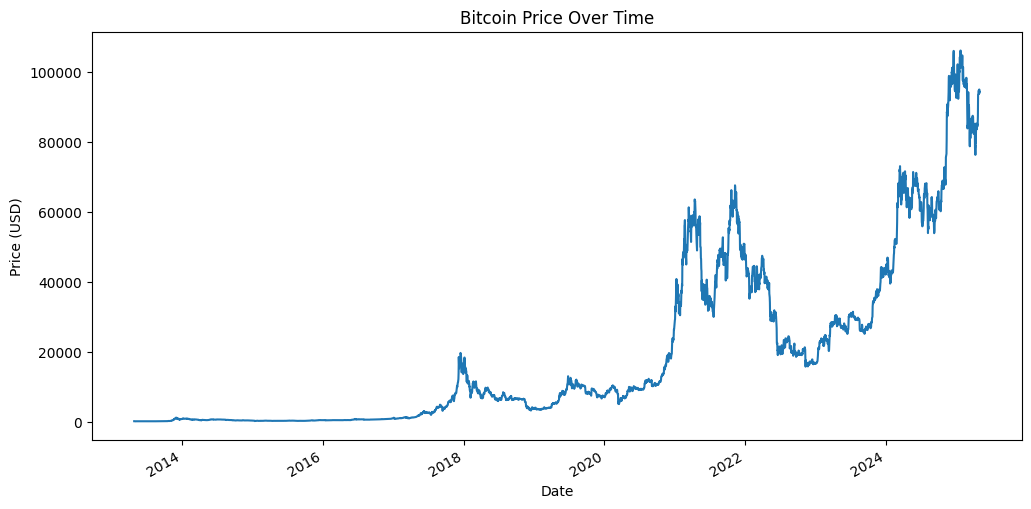

In [3]:
import matplotlib.pyplot as plt

# Plot Bitcoin price over time
plt.figure(figsize=(12,6))
df['price'].plot()
plt.title('Bitcoin Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


2️⃣ Log Scale Price Plot


Bitcoin price spans many orders of magnitude; a log plot can be insightful:


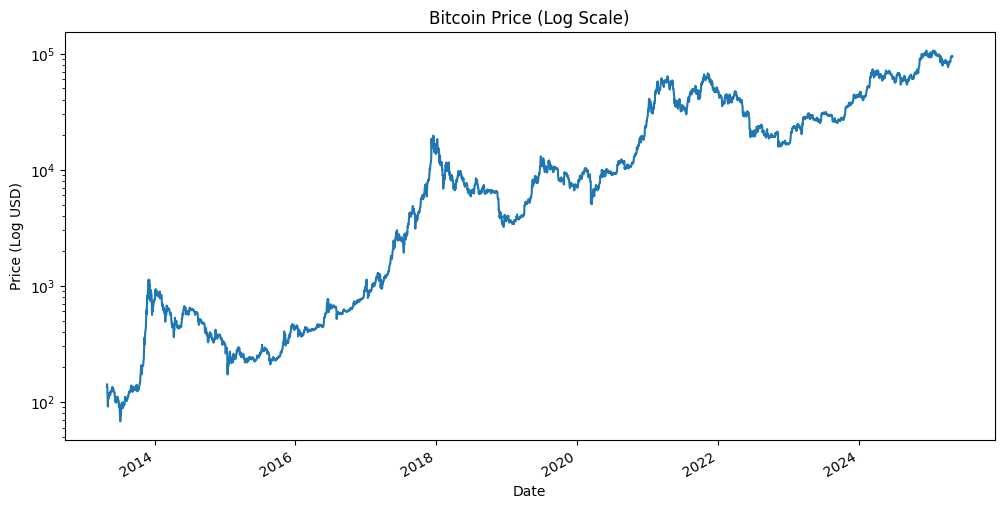

In [4]:
plt.figure(figsize=(12,6))
df['price'].plot(logy=True)
plt.title('Bitcoin Price (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Price (Log USD)')
plt.show()


3️⃣ Volume vs. Price (Scatter Plot)

Shows relationship between trading volume and price.

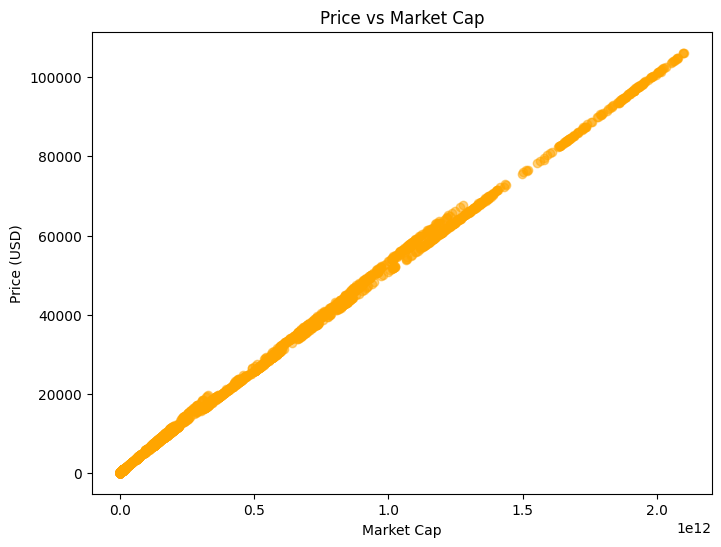

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df['market_cap'], df['price'], alpha=0.5, color='orange')
plt.title('Price vs Market Cap')
plt.xlabel('Market Cap')
plt.ylabel('Price (USD)')
plt.show()


5️⃣ Simple Moving Average (SMA)

You can overlay moving averages to show trends.

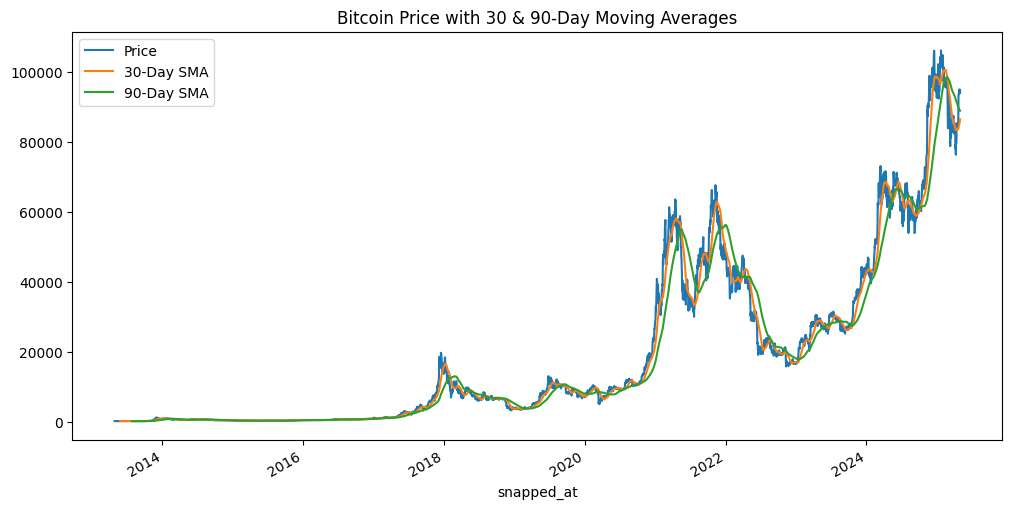

In [6]:
df['SMA_30'] = df['price'].rolling(window=30).mean()
df['SMA_90'] = df['price'].rolling(window=90).mean()

plt.figure(figsize=(12,6))
df['price'].plot(label='Price')
df['SMA_30'].plot(label='30-Day SMA')
df['SMA_90'].plot(label='90-Day SMA')
plt.title('Bitcoin Price with 30 & 90-Day Moving Averages')
plt.legend()
plt.show()


6️⃣ Missing Data Heatmap

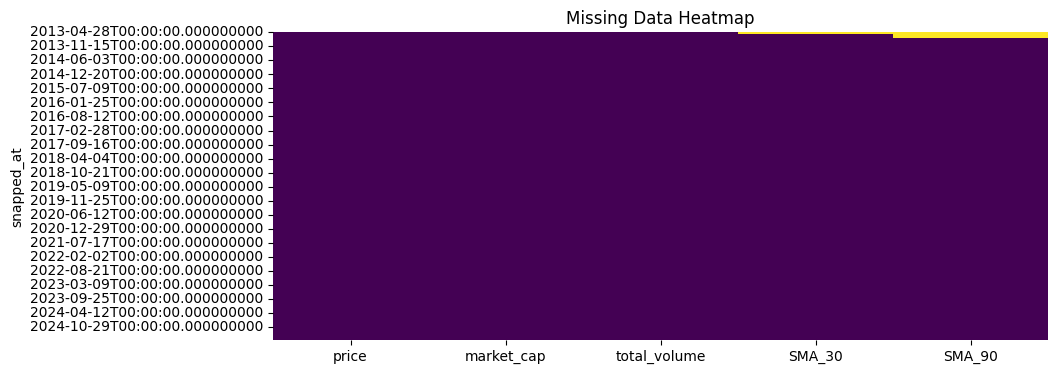

In [7]:
import seaborn as sns

plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


## Add Technical Features

We enrich the dataset with useful features like returns, moving averages, and lag features.


In [8]:
# Add engineered features
df = technical_features(df)

# Check the result
df.tail()

INFO:bitcoin_utils:Adding technical feature columns
INFO:bitcoin_utils:Feature engineering complete


,price,market_cap,total_volume,SMA_30,SMA_90,returns,SMA_7,volatility_7,volatility_30,lag_1day
snapped_at,,,,,,,,,,
2025-04-27 00:00:00+00:00,94644.066371,1.879132e+12,1.544539e+10,84944.749173,89294.226230,-0.001362,91856.689034,3910.916209,4735.202649,94773.112006
2025-04-28 00:00:00+00:00,93809.337820,1.862772e+12,1.592626e+10,85259.744795,89203.680322,-0.008820,93104.713659,2538.545528,5001.737256,94644.066371
2025-04-29 00:00:00+00:00,95030.606455,1.887067e+12,3.191381e+10,85671.459258,89133.874697,0.013019,94187.365011,607.832944,5282.466157,93809.337820
2025-04-30 00:00:00+00:00,94256.359463,1.870818e+12,2.588263e+10,86068.125203,89028.734476,-0.008147,94284.535522,544.956639,5468.465915,95030.606455
2025-05-01 00:00:00+00:00,94235.753310,1.871350e+12,2.654170e+10,86458.847192,88911.559362,-0.000219,94374.578522,459.408665,5622.364710,94256.359463


## Build and Train LSTM Model

We build a simple LSTM model to predict Bitcoin prices based on historical data.


In [24]:
# Split data into train/test sets (e.g., 80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build the model
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

# Compile
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


NameError: name 'Sequential' is not defined

## Visualize Model Performance

We plot the training and validation loss to observe how the model learns.


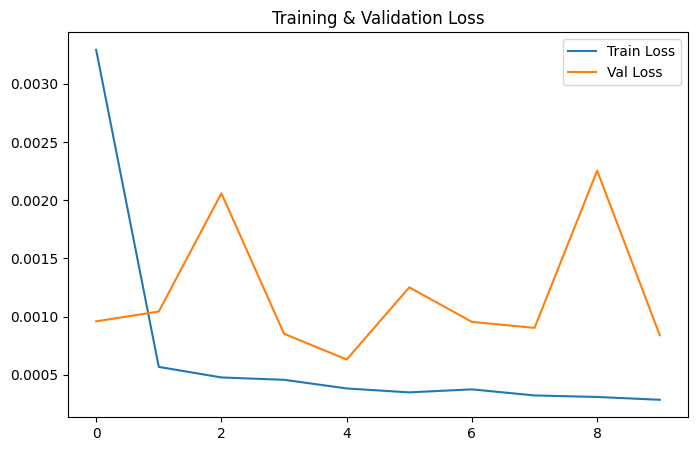

In [ ]:
# Plot training history
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training & Validation Loss')
plt.show()
